Importações

In [ ]:
!pip -q install plotly

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\pedro.lourega\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\pedro.lourega\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
!pip -q install yellowbrick


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\pedro.lourega\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


base_credit = pd.read_csv("content/credit_data.csv")


Leitura do CSV

In [22]:
base_credit = pd.read_csv("content/credit_data.csv")
base_credit

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


Validação dos Dados

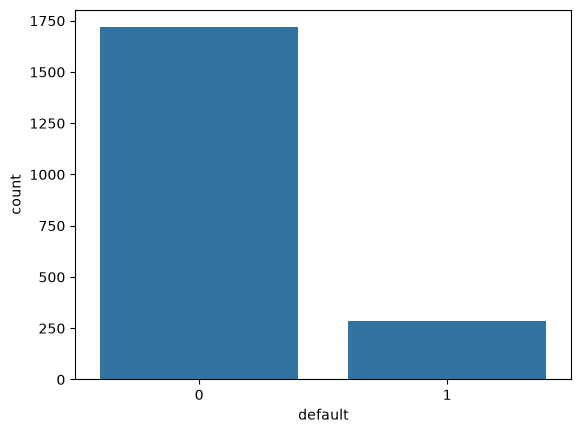

In [ ]:
np.unique(base_credit["default"], return_counts=True)

# gráfico padrão
sns.countplot(x=base_credit["default"]);

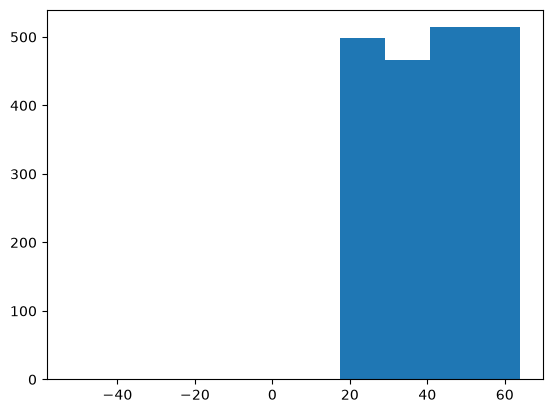

In [ ]:
# gráfico hist idade
plt.hist(x=base_credit["age"]);

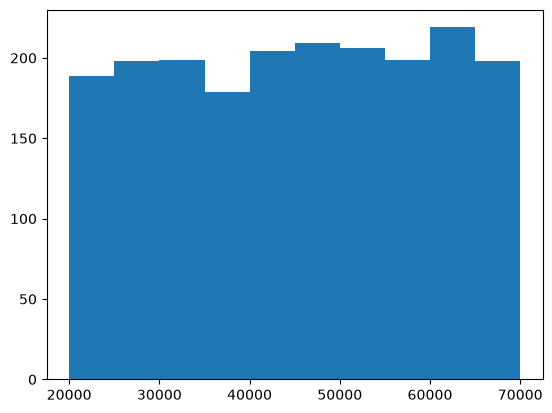

In [18]:
# gráfico tipo hist de renda
plt.hist(x=base_credit["income"]);

In [31]:
grafico = px.scatter_matrix(
    base_credit, dimensions=["age", "income", "loan"], color="default"
)
grafico

Tratamento de Valores Inconsistentes

In [34]:
base_credit.loc[base_credit["age"] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [26]:
# preencher valores inconsistentes

base_credit.mean()
base_credit["age"].mean()
media_age = base_credit["age"][base_credit["age"] > 0].mean()
base_credit.loc[base_credit["age"] < 0, "age"]

15   -28.218361
21   -52.423280
26   -36.496976
Name: age, dtype: float64

In [35]:
base_credit2 = base_credit
base_credit2.loc[base_credit2["age"] < 0, "age"] = media_age

In [36]:
base_credit2.loc[pd.isnull(base_credit["age"])]
base_credit2["age"].fillna(base_credit2["age"].mean(), inplace=True)

C:\Users\pedro.lourega\AppData\Local\Temp\ipykernel_18892\176754809.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  base_credit2["age"].fillna(base_credit2["age"].mean(), inplace=True)


0       59.017015
1       48.117153
2       63.108049
3       45.751972
4       18.584336
          ...    
1995    48.518179
1996    23.162104
1997    28.017167
1998    63.971796
1999    56.152617
Name: age, Length: 2000, dtype: float64

In [37]:
base_credit.loc[
    (base_credit["clientid"] == 29)
    | (base_credit["clientid"] == 31)
    | (base_credit["clientid"] == 32)
]

,clientid,income,age,loan,default
28,29,59417.805406,40.807559,2082.625938,0
30,31,48528.852796,40.807559,6155.784670,0
31,32,23526.302555,40.807559,2862.010139,0


In [29]:
# PRINCIPAL PARA RODAR
base_credit2["age"] = base_credit["age"].fillna(base_credit["age"].mean())

# LEITURA CENSO

In [18]:
base_census = pd.read_csv("content/census.csv")
base_census

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [19]:
# SOMA DE VALORES NULLS
base_census.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

# VISUALIZAÇÃO

In [20]:
grafico_census = px.treemap(base_census, path=["workclass", "age"])
grafico_census.show()

In [ ]:
grafico_census2 = px.treemap(base_census, path=["occupation", "relationship", "age"])
grafico_census2.show()

In [ ]:
grafico_census3 = px.parallel_categories(
    base_census, dimensions=["workclass", "occupation", "income"]
)
grafico_census3.show()